In [1]:
# %matplotlib inline
%time from hikyuu.interactive import *

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:33:21.018 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:33:22,415 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:33:22,415 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:33:22.419 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:33:22.461 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:33:22.499 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:33:22.521 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:33:22.541 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:33:22.714 [HKU-I] - 加载权息数据…… (StockManager.cpp:1170)
2026-09-25 13:33:22.885 [HKU-I] - 加载板块信息…… (StockManager.cpp:214)
2026-09-25 13:33:23.007 [HKU-I] - 加载K线数据…… (StockManager.cpp:221)
2026-09-25 13:33:23.008 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:395)
2026-09-25 13:33:23.008 [HKU-I] - 0.53 秒数据加载完毕. (StockManager.cpp:231)
CPU times: user 2.34 s, sys: 191 ms, total: 2.53 s
Wall time: 3.23 s


# Plot the composite window

Use the create_figure function to quickly create the common composite window for viewing the K-line information of a security

In [2]:
help(create_figure)

Help on function create_figure in module hikyuu.draw.drawplot:

create_figure(n=1, figsize=None)
    Generate a window containing the specified number of axes; at most 4 axes are supported.

    :param int n: the number of the axes
    :param figsize: (width, height)
    :return: (ax1, ax2, ...) depending on the specified number of the axes; None is returned
        when the number is out of [1, 4]



(<Axes: >, <Axes: >, <Axes: >, <Axes: >)

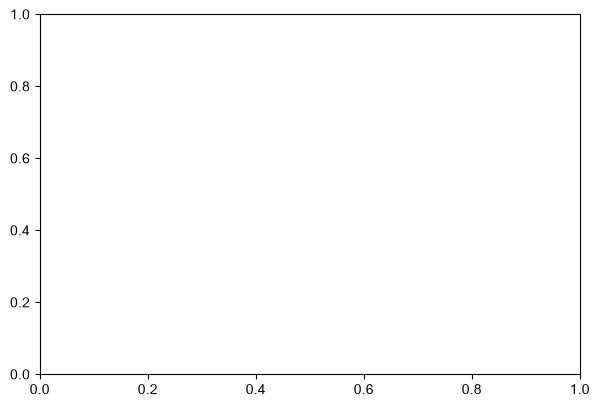

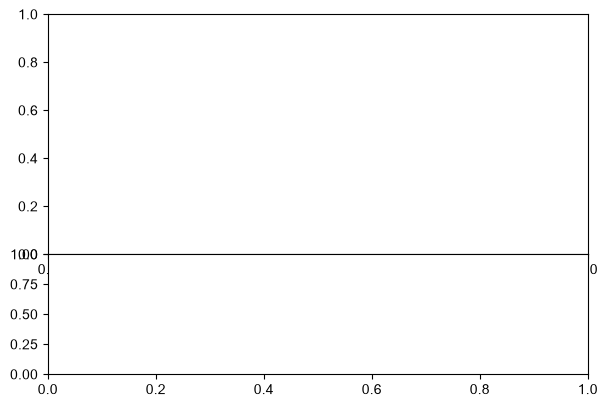

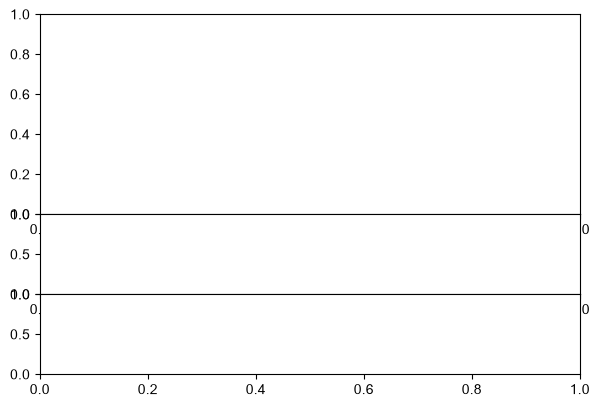

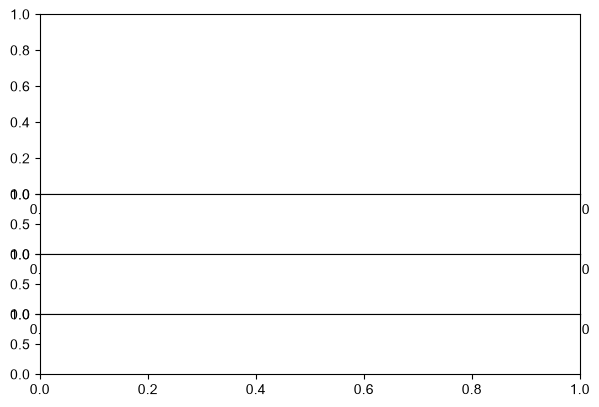

In [3]:
# The display window layout for different numbers of axes
create_figure(figsize=(6,4))
create_figure(2, figsize=(6,4))
create_figure(3, figsize=(6,4))
create_figure(4, figsize=(6,4))

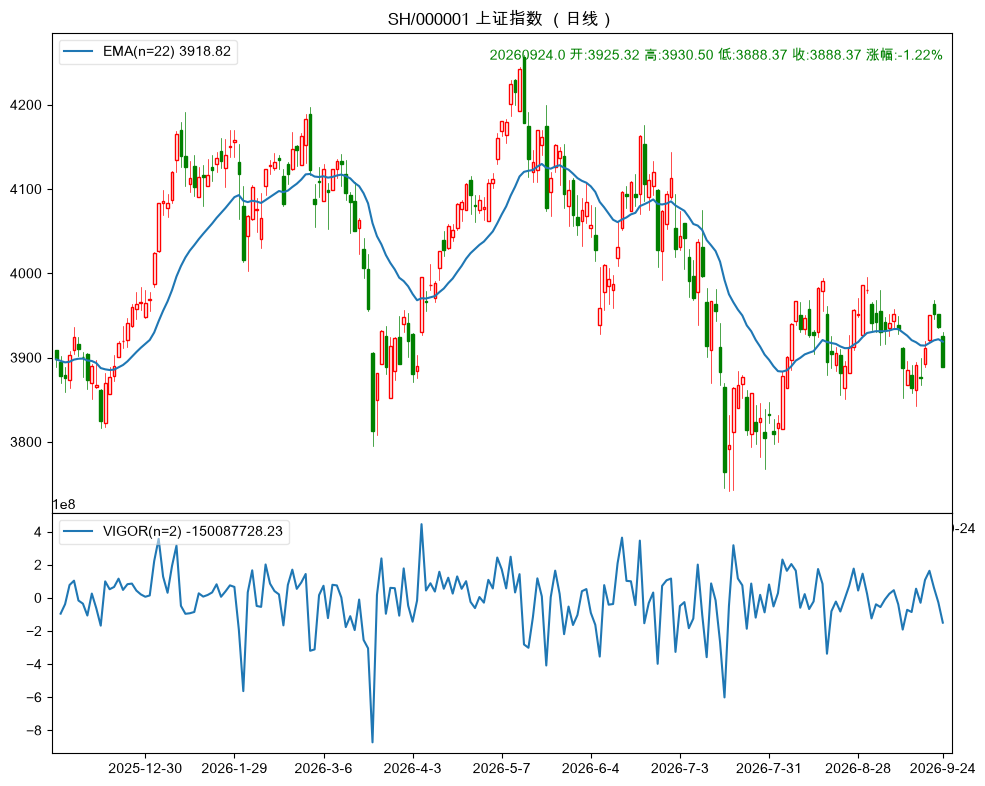

In [4]:
s = sm['sh000001']
k = s.get_kdata(Query(-200))

# Create a window with two display axes
ax1,ax2 = create_figure(2)

# Draw the K-line and EMA in the first axes
k.plot(axes=ax1)
ma = EMA(CLOSE(k))
ma.plot(axes=ax1, legend_on=True)

# Draw the Elder force index in the second axes
v = VIGOR(k)
v.plot(axes=ax2, legend_on=True)

# Plot MACD

Plot MACD:
- ax_draw_macd
- ax_draw_macd2

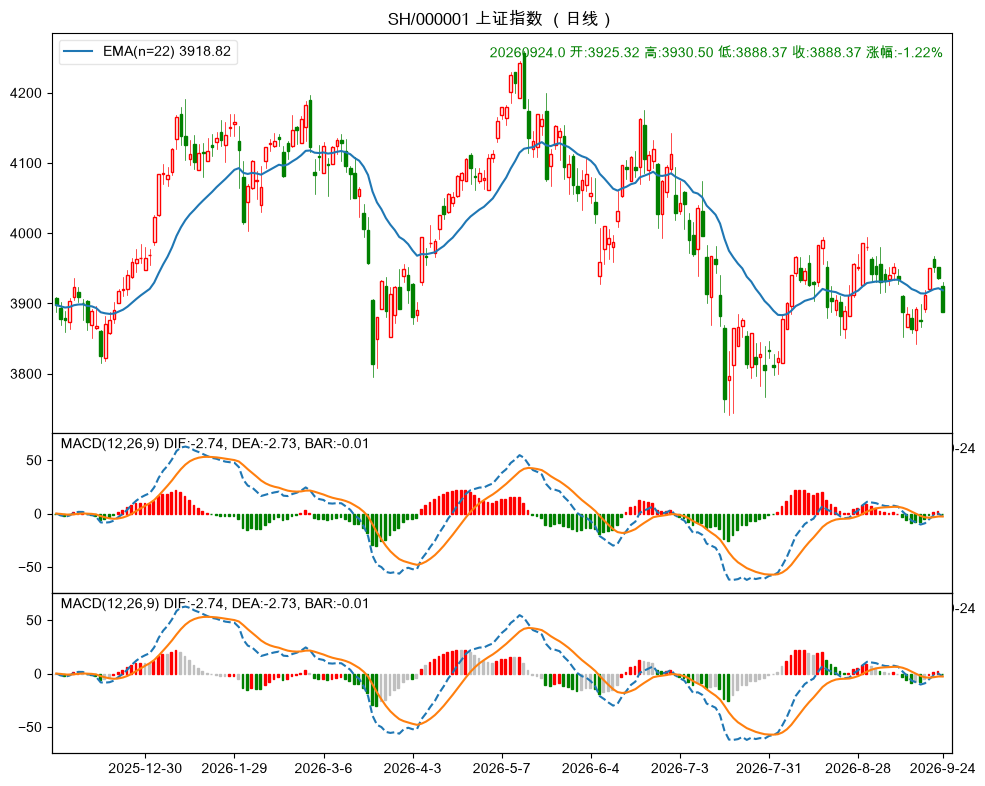

In [5]:
ax1,ax2, ax3 = create_figure(3)

k.plot(axes=ax1)
ma.plot(axes=ax1, legend_on=True)

ax_draw_macd(axes=ax2, kdata=k)
ax_draw_macd2(axes=ax3, ref=ma, kdata=k)

# Three built-in more complex examples

- el.draw plots the Alexander Elder trading system figure
- kf.draw plots the Perry J. Kaufman adaptive moving average system (AMA)
- vl.draw plots a common K-line figure + volume (amount)
- vl.draw2 plots a common K-line figure + volume (amount) + MACD

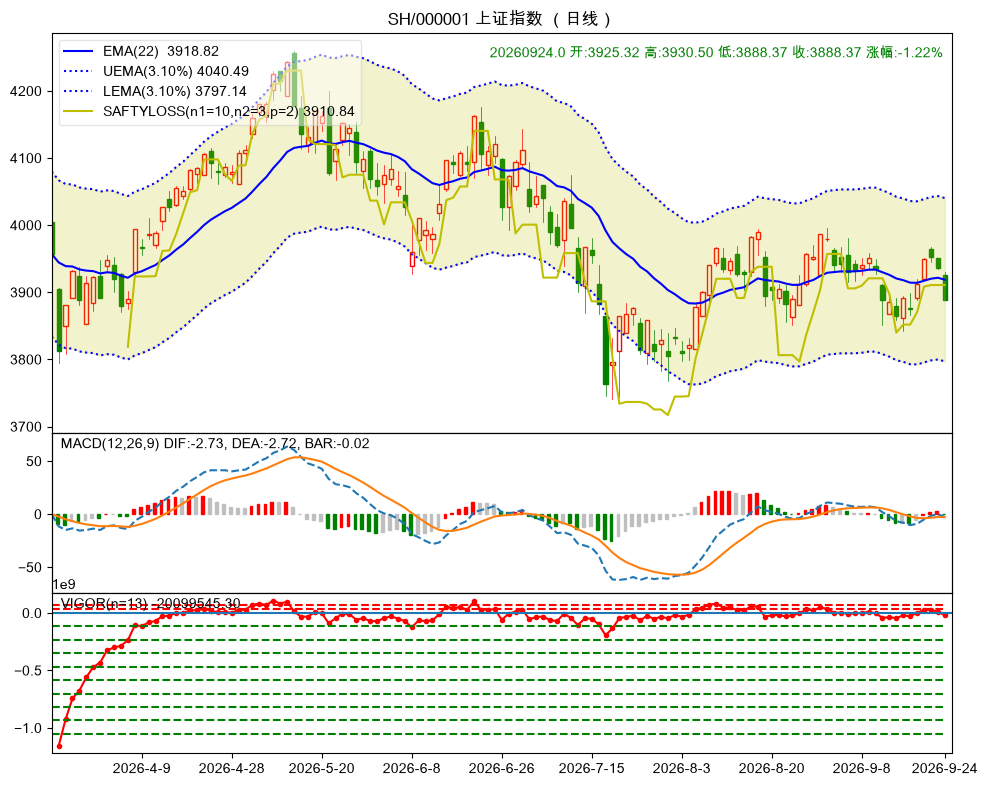

In [6]:
el.draw(s)

/Users/fasiondog/workspace/hikyuu/hikyuu/draw/drawplot/matplotlib_draw.py:482: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = axes.legend(loc='upper left')


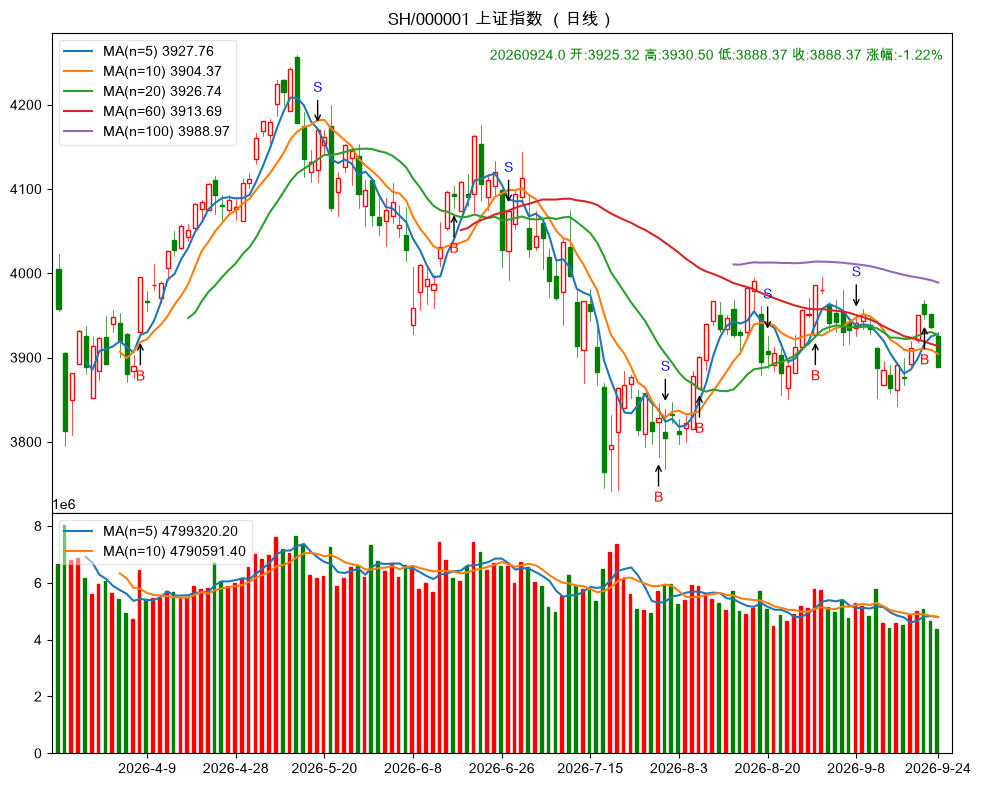

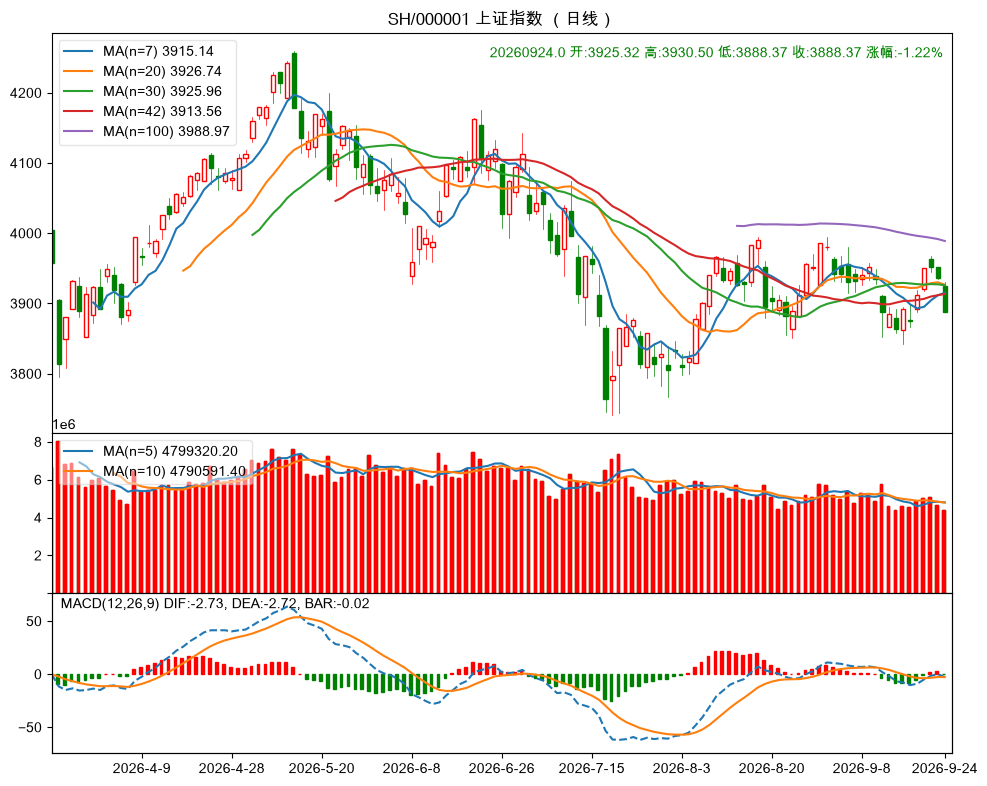

In [7]:
vl.draw(s)
vl.draw2(s)

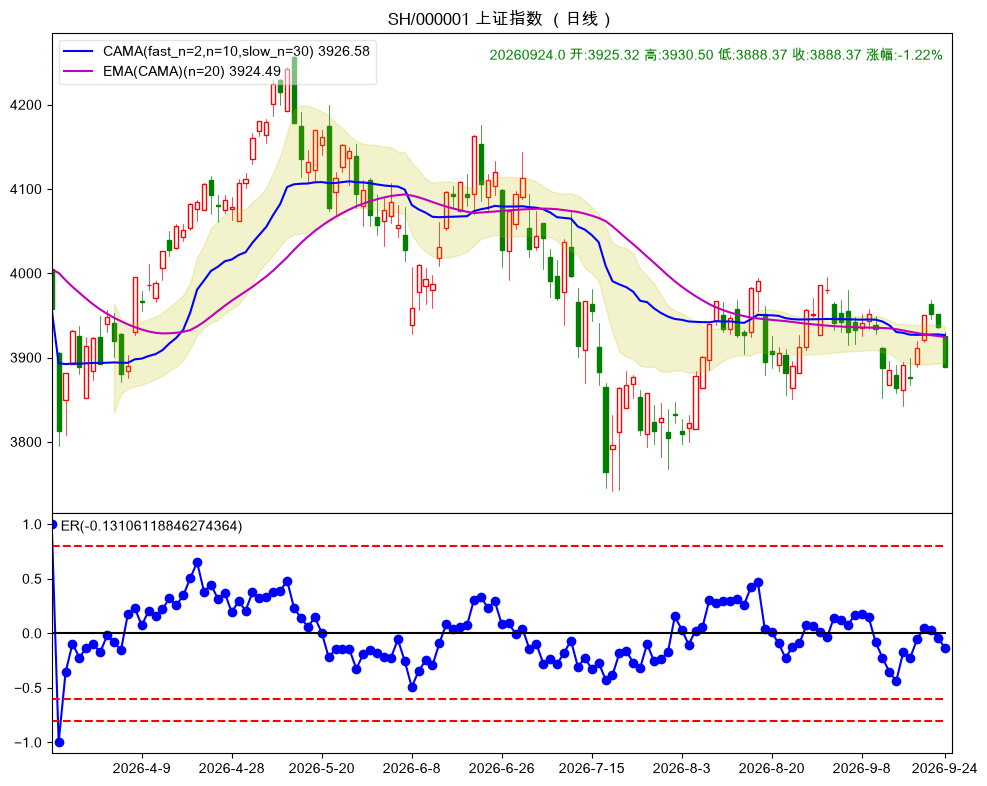

In [8]:
kf.draw(s)